# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna.integration.lightgbm as lgb_optuna

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [42]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [43]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [44]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [45]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [46]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [47]:
print(X_train_final_clean.head())
print(X_test_final_clean.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

   Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                       False        

## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


### Majority class baseline: all features

In [ ]:
# Majority class baseline with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]

# Calculate and print metrics
print("Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))

Accuracy: 0.6148
Recall: 0.2781
Precision: 0.2766
ROC-AUC: 0.5074


### Logistic Regression Model: All features

In [49]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_



Python(12460) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12461) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12462) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12463) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12464) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12465) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12466) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12467) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12468) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12469) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12470) Malloc

In [50]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Montly Charges

In [51]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [52]:
print(best_logreg_monthly_charges_bin)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons except Online Security)

In [53]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons except OnlineSecurity)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [54]:
print(best_logreg_internet_service)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [55]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [56]:
print(best_logreg_all_add_ons)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate best Logistic Regression Model: All features

In [57]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.802


Mean cross-validated precision: 0.5262
Mean cross-validated ROC-AUC: 0.8479


### Evaluate Best Logistic Regression Model: Binned Monthly Charges

In [58]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8
Mean cross-validated precision: 0.5163
Mean cross-validated ROC-AUC: 0.8339


### Evaluate Best Logistic Regression Model: Internet Service plus Online Security Add-on

In [59]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Internet Service Model")
print("Best parameters:", internet_service_grid.best_params_)
print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))
internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

Results for Pruned Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.804
Mean cross-validated precision: 0.5227
Mean cross-validated ROC-AUC: 0.8445


### Evaluate Best Logistic Regression Model: All Add-Ons, no Internet Service

In [60]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))
all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

Results for Pruned All Add-Ons Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8094
Mean cross-validated precision: 0.529
Mean cross-validated ROC-AUC: 0.8469


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

### LightGBM Hyperparameter Tuning: All features

In [61]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-01-30 14:16:31,105] A new study created in memory with name: no-name-bd6d2611-12fb-4125-9679-c8a02bc2e349
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:24<02:28, 24.73s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:30<01:07, 13.44s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:34<00:37,  9.33s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:40<00:23,  7.93s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:46<00:14,  7.24s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:51<00:06,  6.41s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:59<00:00,  8.48s/it]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:   5%|5         | 1/20 [00:20<06:35, 20.83s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842326 + 0.0051235
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  10%|#         | 2/20 [00:36<05:21, 17.84s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842988 + 0.00462308
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  15%|#5        | 3/20 [01:00<05:51, 20.66s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  20%|##        | 4/20 [01:23<05:44, 21.56s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848935:  25%|##5       | 5/20 [01:26<03:42, 14.85s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.848935 + 0.00429003
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  30%|###       | 6/20 [01:28<02:27, 10.53s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  35%|###5      | 7/20 [01:31<01:45,  8.15s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.849355 + 0.00426994
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  40%|####      | 8/20 [01:35<01:20,  6.70s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  45%|####5     | 9/20 [01:42<01:15,  6.90s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.845112 + 0.00449233
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  50%|#####     | 10/20 [01:44<00:53,  5.33s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  55%|#####5    | 11/20 [02:02<01:23,  9.25s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845317 + 0.00497013
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  60%|######    | 12/20 [02:09<01:06,  8.36s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84155 + 0.00412659
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  65%|######5   | 13/20 [02:29<01:24, 12.01s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.842623 + 0.0044621
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  70%|#######   | 14/20 [02:34<00:59,  9.98s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84773 + 0.0054634
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  75%|#######5  | 15/20 [02:38<00:40,  8.08s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  80%|########  | 16/20 [02:45<00:31,  7.86s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.847774 + 0.00485876
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  85%|########5 | 17/20 [02:47<00:17,  5.93s/it]

Early stopping, best iteration is:
[89]	valid's auc: 0.849958 + 0.00433803
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  90%|######### | 18/20 [02:55<00:13,  6.52s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.843972 + 0.00474895
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  95%|#########5| 19/20 [03:05<00:07,  7.64s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.847774 + 0.00485876
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700: 100%|##########| 20/20 [03:28<00:00, 10.43s/it]


Early stopping, best iteration is:
[18]	valid's auc: 0.841654 + 0.00578883


bagging, val_score: 0.850700:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  10%|#         | 1/10 [00:02<00:24,  2.75s/it]

Early stopping, best iteration is:
[326]	valid's auc: 0.850627 + 0.00424089
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  20%|##        | 2/10 [00:06<00:28,  3.62s/it]

Early stopping, best iteration is:
[233]	valid's auc: 0.850626 + 0.00469775
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  30%|###       | 3/10 [00:11<00:28,  4.00s/it]

Early stopping, best iteration is:
[233]	valid's auc: 0.850368 + 0.00502159
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  40%|####      | 4/10 [00:14<00:21,  3.53s/it]

Early stopping, best iteration is:
[233]	valid's auc: 0.850233 + 0.004662
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  50%|#####     | 5/10 [00:18<00:19,  3.95s/it]

Early stopping, best iteration is:
[237]	valid's auc: 0.850219 + 0.00481406
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  60%|######    | 6/10 [00:21<00:13,  3.37s/it]

Early stopping, best iteration is:
[233]	valid's auc: 0.850298 + 0.00460274
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  70%|#######   | 7/10 [00:22<00:08,  2.86s/it]

Early stopping, best iteration is:
[185]	valid's auc: 0.850628 + 0.00517502
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850807:  80%|########  | 8/10 [00:24<00:05,  2.57s/it]

Early stopping, best iteration is:
[212]	valid's auc: 0.850807 + 0.00465565
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850807:  90%|######### | 9/10 [00:27<00:02,  2.57s/it]

Early stopping, best iteration is:
[143]	valid's auc: 0.849853 + 0.0045588
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850807: 100%|##########| 10/10 [00:37<00:00,  3.70s/it]


Early stopping, best iteration is:
[181]	valid's auc: 0.850647 + 0.0048205


feature_fraction_stage2, val_score: 0.850807:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850932:  33%|###3      | 1/3 [00:06<00:12,  6.24s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850932 + 0.00487594
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850932:  67%|######6   | 2/3 [00:11<00:05,  5.39s/it]

Early stopping, best iteration is:
[189]	valid's auc: 0.850494 + 0.00405877
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850932: 100%|##########| 3/3 [00:20<00:00,  6.77s/it]


Early stopping, best iteration is:
[212]	valid's auc: 0.850719 + 0.00498515


regularization_factors, val_score: 0.850932:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:   5%|5         | 1/20 [00:04<01:30,  4.78s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  10%|#         | 2/20 [00:08<01:09,  3.86s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  15%|#5        | 3/20 [00:12<01:08,  4.03s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  20%|##        | 4/20 [00:15<00:56,  3.54s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  25%|##5       | 5/20 [00:21<01:11,  4.75s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  30%|###       | 6/20 [00:24<00:58,  4.17s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  35%|###5      | 7/20 [00:28<00:50,  3.85s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  40%|####      | 8/20 [00:30<00:39,  3.26s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  45%|####5     | 9/20 [00:32<00:31,  2.85s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  50%|#####     | 10/20 [00:35<00:30,  3.08s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  55%|#####5    | 11/20 [00:37<00:24,  2.73s/it]

Early stopping, best iteration is:
[212]	valid's auc: 0.850896 + 0.00505274
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  60%|######    | 12/20 [00:39<00:19,  2.48s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  65%|######5   | 13/20 [00:41<00:16,  2.41s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850933 + 0.00487467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850933:  70%|#######   | 14/20 [00:45<00:16,  2.73s/it]

Early stopping, best iteration is:
[210]	valid's auc: 0.850932 + 0.00487594
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850939:  75%|#######5  | 15/20 [00:47<00:13,  2.60s/it]

Early stopping, best iteration is:
[212]	valid's auc: 0.850939 + 0.00506689
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850954:  80%|########  | 16/20 [00:49<00:09,  2.37s/it]

Early stopping, best iteration is:
[212]	valid's auc: 0.850954 + 0.00504624
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850954:  85%|########5 | 17/20 [00:51<00:06,  2.19s/it]

Early stopping, best iteration is:
[212]	valid's auc: 0.850924 + 0.00512468
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850975:  90%|######### | 18/20 [00:54<00:05,  2.63s/it]

Early stopping, best iteration is:
[185]	valid's auc: 0.850975 + 0.00428784
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850975:  95%|#########5| 19/20 [01:00<00:03,  3.68s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.850926 + 0.00446606
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850975: 100%|##########| 20/20 [01:04<00:00,  3.25s/it]


Early stopping, best iteration is:
[413]	valid's auc: 0.849981 + 0.00462456


min_child_samples, val_score: 0.850975:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850992:  20%|##        | 1/5 [00:02<00:09,  2.45s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.850992 + 0.00465496
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850999:  40%|####      | 2/5 [00:05<00:08,  2.84s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.850999 + 0.00454989
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850999:  60%|######    | 3/5 [00:06<00:04,  2.04s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.850832 + 0.00441494
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850999:  80%|########  | 4/5 [00:07<00:01,  1.59s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.85086 + 0.00436045
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850999: 100%|##########| 5/5 [00:08<00:00,  1.72s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.850876 + 0.00451001


In [62]:
# Get best parameters and best score for LightGBM for All features
print('LightGBM: All features')
print('Best params:', optuna_lgbm.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='recall')
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='precision')
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='roc_auc')
print('Mean cross-validated recall:', round(cv_recall.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.05084365808795097, 'lambda_l2': 0.0007440303876361581, 'num_leaves': 2, 'feature_fraction': 0.44800000000000006, 'bagging_fraction': 0.5308181845300608, 'bagging_freq': 6, 'min_child_samples': 100}


Mean cross-validated recall: 0.8174
Mean cross-validated precision: 0.5098
Mean cross-validated ROC-AUC: 0.8457


### LightGBM Model: Monthy Charges Pruned Feature Set


In [63]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_monthly_charges.run()


[I 2026-01-30 14:23:12,622] A new study created in memory with name: no-name-b9fe2829-7170-429e-aa92-28c812b1b82f


feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.838618:  14%|#4        | 1/7 [00:01<00:06,  1.07s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838618 + 0.00859176
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  29%|##8       | 2/7 [00:01<00:04,  1.11it/s]

Early stopping, best iteration is:
[16]	valid's auc: 0.840054 + 0.00799637
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  43%|####2     | 3/7 [00:03<00:04,  1.02s/it]

Early stopping, best iteration is:
[38]	valid's auc: 0.839316 + 0.00848273
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  57%|#####7    | 4/7 [00:03<00:02,  1.24it/s]

Early stopping, best iteration is:
[14]	valid's auc: 0.840203 + 0.00917435
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  71%|#######1  | 5/7 [00:04<00:02,  1.03s/it]

Early stopping, best iteration is:
[58]	valid's auc: 0.839946 + 0.00888216
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  86%|########5 | 6/7 [00:05<00:00,  1.02it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.839769 + 0.00849886
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840594: 100%|##########| 7/7 [00:06<00:00,  1.08it/s]


Early stopping, best iteration is:
[18]	valid's auc: 0.840594 + 0.00920103


num_leaves, val_score: 0.840594:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:   5%|5         | 1/20 [00:02<00:53,  2.79s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  10%|#         | 2/20 [00:04<00:40,  2.24s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  15%|#5        | 3/20 [00:05<00:27,  1.61s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839654 + 0.00997592
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  20%|##        | 4/20 [00:06<00:21,  1.35s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  25%|##5       | 5/20 [00:06<00:15,  1.04s/it]

Early stopping, best iteration is:
[94]	valid's auc: 0.842463 + 0.00806052
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  30%|###       | 6/20 [00:07<00:12,  1.16it/s]

Early stopping, best iteration is:
[18]	valid's auc: 0.841723 + 0.00775666
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  35%|###5      | 7/20 [00:08<00:11,  1.16it/s]

Early stopping, best iteration is:
[214]	valid's auc: 0.843885 + 0.00874871
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  40%|####      | 8/20 [00:09<00:11,  1.06it/s]

Early stopping, best iteration is:
[11]	valid's auc: 0.839134 + 0.00911806
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  45%|####5     | 9/20 [00:09<00:08,  1.26it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.843965 + 0.00825297
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  50%|#####     | 10/20 [00:10<00:08,  1.20it/s]

Early stopping, best iteration is:
[6]	valid's auc: 0.839199 + 0.00976822
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  55%|#####5    | 11/20 [00:13<00:13,  1.47s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  60%|######    | 12/20 [00:15<00:11,  1.42s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839965 + 0.0101428
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  65%|######5   | 13/20 [00:17<00:11,  1.60s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  70%|#######   | 14/20 [00:17<00:07,  1.33s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.840362 + 0.00921773
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  75%|#######5  | 15/20 [00:18<00:05,  1.16s/it]

Early stopping, best iteration is:
[214]	valid's auc: 0.843885 + 0.00874871
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  80%|########  | 16/20 [00:19<00:04,  1.07s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.840318 + 0.00818636
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  85%|########5 | 17/20 [00:20<00:03,  1.10s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.838713 + 0.00914008
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  90%|######### | 18/20 [00:21<00:01,  1.08it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.843965 + 0.00825297
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  95%|#########5| 19/20 [00:21<00:00,  1.16it/s]

Early stopping, best iteration is:
[11]	valid's auc: 0.840529 + 0.00903724
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536: 100%|##########| 20/20 [00:24<00:00,  1.21s/it]


Early stopping, best iteration is:
[6]	valid's auc: 0.839575 + 0.00968915


bagging, val_score: 0.844536:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  10%|#         | 1/10 [00:00<00:08,  1.05it/s]

Early stopping, best iteration is:
[284]	valid's auc: 0.843865 + 0.00761453
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  20%|##        | 2/10 [00:01<00:07,  1.04it/s]

Early stopping, best iteration is:
[242]	valid's auc: 0.843743 + 0.00729373
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  30%|###       | 3/10 [00:02<00:06,  1.08it/s]

Early stopping, best iteration is:
[321]	valid's auc: 0.844114 + 0.00804338
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  40%|####      | 4/10 [00:03<00:05,  1.10it/s]

Early stopping, best iteration is:
[321]	valid's auc: 0.844135 + 0.00807838
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  50%|#####     | 5/10 [00:04<00:04,  1.10it/s]

Early stopping, best iteration is:
[320]	valid's auc: 0.844138 + 0.00810881
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  60%|######    | 6/10 [00:05<00:03,  1.04it/s]

Early stopping, best iteration is:
[319]	valid's auc: 0.844035 + 0.00803865
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  70%|#######   | 7/10 [00:06<00:02,  1.05it/s]

Early stopping, best iteration is:
[318]	valid's auc: 0.843999 + 0.00800926
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  80%|########  | 8/10 [00:12<00:04,  2.47s/it]

Early stopping, best iteration is:
[320]	valid's auc: 0.844072 + 0.00826725
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  90%|######### | 9/10 [00:13<00:02,  2.13s/it]

Early stopping, best iteration is:
[391]	valid's auc: 0.844425 + 0.00743448
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536: 100%|##########| 10/10 [00:14<00:00,  1.46s/it]


Early stopping, best iteration is:
[320]	valid's auc: 0.844014 + 0.00773098


feature_fraction_stage2, val_score: 0.844536:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844542:  17%|#6        | 1/6 [00:01<00:05,  1.11s/it]

Early stopping, best iteration is:
[441]	valid's auc: 0.844542 + 0.00763901
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844542:  33%|###3      | 2/6 [00:02<00:04,  1.06s/it]

Early stopping, best iteration is:
[458]	valid's auc: 0.844524 + 0.00758311
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844664:  50%|#####     | 3/6 [00:03<00:03,  1.22s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844664:  67%|######6   | 4/6 [00:04<00:02,  1.16s/it]

Early stopping, best iteration is:
[495]	valid's auc: 0.844569 + 0.00757868
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844664:  83%|########3 | 5/6 [00:05<00:01,  1.16s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844664: 100%|##########| 6/6 [00:08<00:00,  1.34s/it]


Early stopping, best iteration is:
[441]	valid's auc: 0.844542 + 0.00763901


regularization_factors, val_score: 0.844664:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:   5%|5         | 1/20 [00:01<00:30,  1.60s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  10%|#         | 2/20 [00:03<00:28,  1.58s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  15%|#5        | 3/20 [00:04<00:27,  1.60s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  20%|##        | 4/20 [00:06<00:26,  1.64s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  25%|##5       | 5/20 [00:08<00:24,  1.66s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  30%|###       | 6/20 [00:11<00:29,  2.10s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  35%|###5      | 7/20 [00:13<00:29,  2.26s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  40%|####      | 8/20 [00:16<00:30,  2.52s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844664:  45%|####5     | 9/20 [00:19<00:29,  2.69s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844664 + 0.00768677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  50%|#####     | 10/20 [00:22<00:27,  2.77s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  55%|#####5    | 11/20 [00:25<00:23,  2.67s/it]

Early stopping, best iteration is:
[479]	valid's auc: 0.844572 + 0.00757786
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  60%|######    | 12/20 [00:26<00:18,  2.35s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  65%|######5   | 13/20 [00:28<00:15,  2.16s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  70%|#######   | 14/20 [00:30<00:13,  2.17s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  75%|#######5  | 15/20 [00:34<00:12,  2.48s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  80%|########  | 16/20 [00:35<00:08,  2.20s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  85%|########5 | 17/20 [00:37<00:06,  2.08s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  90%|######### | 18/20 [00:40<00:04,  2.26s/it]

Early stopping, best iteration is:
[493]	valid's auc: 0.844576 + 0.00755654
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665:  95%|#########5| 19/20 [00:41<00:02,  2.09s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844665: 100%|##########| 20/20 [00:43<00:00,  2.17s/it]


Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481


min_child_samples, val_score: 0.844665:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844665:  20%|##        | 1/5 [00:05<00:21,  5.34s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844665:  40%|####      | 2/5 [00:08<00:12,  4.10s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844665:  60%|######    | 3/5 [00:10<00:06,  3.03s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844665:  80%|########  | 4/5 [00:12<00:02,  2.49s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844665: 100%|##########| 5/5 [00:14<00:00,  2.98s/it]

Early stopping, best iteration is:
[704]	valid's auc: 0.844665 + 0.00768481


In [ ]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))

LightGBM montly charges model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 1.9498116498403953e-06, 'lambda_l2': 0.00033077305850689955, 'num_leaves': 2, 'feature_fraction': 0.88, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 20}
Mean cross-validated recall: 0.8134
Mean cross-validated precision: 0.4974
Mean cross-validated ROC-AUC: 0.8355


### LightGBM Model: Internet Service Pruned Feature Set

In [65]:
# Create pruned feature set for Monthly Charges
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_internet_service.run()


[I 2026-01-30 14:25:04,863] A new study created in memory with name: no-name-667314d7-7043-4b57-abb9-fdc89883dffa
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  14%|#4        | 1/7 [00:00<00:04,  1.45it/s]

Early stopping, best iteration is:
[10]	valid's auc: 0.839234 + 0.0103139
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  29%|##8       | 2/7 [00:01<00:03,  1.26it/s]

Early stopping, best iteration is:
[43]	valid's auc: 0.837897 + 0.00882177
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  43%|####2     | 3/7 [00:02<00:03,  1.27it/s]

Early stopping, best iteration is:
[46]	valid's auc: 0.836495 + 0.00923247
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  57%|#####7    | 4/7 [00:03<00:02,  1.33it/s]

Early stopping, best iteration is:
[18]	valid's auc: 0.839554 + 0.00952429
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  71%|#######1  | 5/7 [00:04<00:01,  1.06it/s]

Early stopping, best iteration is:
[59]	valid's auc: 0.836462 + 0.00895202
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841138:  86%|########5 | 6/7 [00:05<00:00,  1.14it/s]

Early stopping, best iteration is:
[19]	valid's auc: 0.841138 + 0.00869123
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841619: 100%|##########| 7/7 [00:05<00:00,  1.22it/s]


Early stopping, best iteration is:
[22]	valid's auc: 0.841619 + 0.00884165


num_leaves, val_score: 0.841619:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:   5%|5         | 1/20 [00:03<01:05,  3.45s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833088 + 0.0105925
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  10%|#         | 2/20 [00:05<00:43,  2.43s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  15%|#5        | 3/20 [00:06<00:33,  1.99s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.834519 + 0.00965963
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843286:  20%|##        | 4/20 [00:07<00:22,  1.40s/it]

Early stopping, best iteration is:
[28]	valid's auc: 0.843286 + 0.00855064
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843320:  25%|##5       | 5/20 [00:07<00:16,  1.12s/it]

Early stopping, best iteration is:
[39]	valid's auc: 0.84332 + 0.00799084
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  30%|###       | 6/20 [00:08<00:15,  1.08s/it]

Early stopping, best iteration is:
[371]	valid's auc: 0.84383 + 0.00762326
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  35%|###5      | 7/20 [00:09<00:11,  1.10it/s]

Early stopping, best iteration is:
[26]	valid's auc: 0.842859 + 0.00825826
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  40%|####      | 8/20 [00:09<00:09,  1.25it/s]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  45%|####5     | 9/20 [00:10<00:09,  1.14it/s]

Early stopping, best iteration is:
[13]	valid's auc: 0.835049 + 0.0104923
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  50%|#####     | 10/20 [00:12<00:09,  1.03it/s]

Early stopping, best iteration is:
[15]	valid's auc: 0.8349 + 0.0104913
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  55%|#####5    | 11/20 [00:15<00:15,  1.73s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  60%|######    | 12/20 [00:16<00:11,  1.50s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838577 + 0.010394
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  65%|######5   | 13/20 [00:17<00:08,  1.28s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838308 + 0.0101258
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  70%|#######   | 14/20 [00:19<00:09,  1.55s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833508 + 0.0108146
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  75%|#######5  | 15/20 [00:20<00:06,  1.24s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.843666 + 0.00869392
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  80%|########  | 16/20 [00:20<00:04,  1.03s/it]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  85%|########5 | 17/20 [00:21<00:02,  1.04it/s]

Early stopping, best iteration is:
[22]	valid's auc: 0.839404 + 0.00912707
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  90%|######### | 18/20 [00:23<00:02,  1.19s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.83365 + 0.0105465
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  95%|#########5| 19/20 [00:23<00:01,  1.09s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.839139 + 0.00870838
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830: 100%|##########| 20/20 [00:24<00:00,  1.23s/it]


Early stopping, best iteration is:
[18]	valid's auc: 0.840891 + 0.00904424


bagging, val_score: 0.843830:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  10%|#         | 1/10 [00:02<00:23,  2.63s/it]

Early stopping, best iteration is:
[382]	valid's auc: 0.843634 + 0.00803822
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  20%|##        | 2/10 [00:03<00:13,  1.64s/it]

Early stopping, best iteration is:
[280]	valid's auc: 0.843507 + 0.0082168
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  30%|###       | 3/10 [00:04<00:09,  1.35s/it]

Early stopping, best iteration is:
[328]	valid's auc: 0.843028 + 0.00804846
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  40%|####      | 4/10 [00:05<00:07,  1.28s/it]

Early stopping, best iteration is:
[398]	valid's auc: 0.843549 + 0.00787344
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  50%|#####     | 5/10 [00:06<00:06,  1.23s/it]

Early stopping, best iteration is:
[377]	valid's auc: 0.842774 + 0.0080589
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843830:  60%|######    | 6/10 [00:08<00:04,  1.21s/it]

Early stopping, best iteration is:
[296]	valid's auc: 0.842556 + 0.00829263
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843836:  70%|#######   | 7/10 [00:09<00:03,  1.23s/it]

Early stopping, best iteration is:
[402]	valid's auc: 0.843836 + 0.00784805
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843836:  80%|########  | 8/10 [00:10<00:02,  1.20s/it]

Early stopping, best iteration is:
[346]	valid's auc: 0.843646 + 0.00770396
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843836:  90%|######### | 9/10 [00:11<00:01,  1.26s/it]

Early stopping, best iteration is:
[421]	valid's auc: 0.843558 + 0.00791687
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.843836: 100%|##########| 10/10 [00:13<00:00,  1.33s/it]


Early stopping, best iteration is:
[446]	valid's auc: 0.84344 + 0.00809528


feature_fraction_stage2, val_score: 0.843836:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860:  17%|#6        | 1/6 [00:02<00:12,  2.54s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860:  33%|###3      | 2/6 [00:03<00:06,  1.74s/it]

Early stopping, best iteration is:
[427]	valid's auc: 0.843762 + 0.00793877
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860:  50%|#####     | 3/6 [00:08<00:08,  2.90s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.843798 + 0.00776745
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860:  67%|######6   | 4/6 [00:10<00:05,  2.60s/it]

Early stopping, best iteration is:
[402]	valid's auc: 0.843761 + 0.00783265
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860:  83%|########3 | 5/6 [00:11<00:02,  2.29s/it]

Early stopping, best iteration is:
[402]	valid's auc: 0.843836 + 0.00784805
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.843860: 100%|##########| 6/6 [00:13<00:00,  2.25s/it]


Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321


regularization_factors, val_score: 0.843860:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:   5%|5         | 1/20 [00:01<00:35,  1.87s/it]

Early stopping, best iteration is:
[422]	valid's auc: 0.843828 + 0.00783337
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  10%|#         | 2/20 [00:03<00:29,  1.66s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  15%|#5        | 3/20 [00:04<00:24,  1.45s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  20%|##        | 4/20 [00:07<00:30,  1.90s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  25%|##5       | 5/20 [00:08<00:24,  1.63s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  30%|###       | 6/20 [00:09<00:20,  1.46s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  35%|###5      | 7/20 [00:10<00:17,  1.37s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  40%|####      | 8/20 [00:12<00:16,  1.37s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  45%|####5     | 9/20 [00:14<00:18,  1.68s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  50%|#####     | 10/20 [00:15<00:14,  1.48s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  55%|#####5    | 11/20 [00:17<00:16,  1.82s/it]

Early stopping, best iteration is:
[638]	valid's auc: 0.843755 + 0.00758378
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  60%|######    | 12/20 [00:19<00:13,  1.66s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  65%|######5   | 13/20 [00:24<00:19,  2.76s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  70%|#######   | 14/20 [00:26<00:15,  2.55s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  75%|#######5  | 15/20 [00:29<00:12,  2.54s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  80%|########  | 16/20 [00:32<00:11,  2.90s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  85%|########5 | 17/20 [00:35<00:08,  2.87s/it]

Early stopping, best iteration is:
[402]	valid's auc: 0.843824 + 0.00771222
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  90%|######### | 18/20 [00:40<00:06,  3.46s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860:  95%|#########5| 19/20 [00:43<00:03,  3.21s/it]

Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.843860: 100%|##########| 20/20 [00:44<00:00,  2.23s/it]


Early stopping, best iteration is:
[386]	valid's auc: 0.84386 + 0.00774321


min_child_samples, val_score: 0.843860:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.843860:  20%|##        | 1/5 [00:01<00:05,  1.41s/it]

Early stopping, best iteration is:
[427]	valid's auc: 0.84356 + 0.00786528
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.843860:  40%|####      | 2/5 [00:02<00:04,  1.43s/it]

Early stopping, best iteration is:
[447]	valid's auc: 0.84364 + 0.00779646
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.843860:  60%|######    | 3/5 [00:06<00:04,  2.46s/it]

Early stopping, best iteration is:
[406]	valid's auc: 0.843826 + 0.0077378
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.843880:  80%|########  | 4/5 [00:20<00:07,  7.08s/it]

Early stopping, best iteration is:
[408]	valid's auc: 0.84388 + 0.00774173
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.843880: 100%|##########| 5/5 [00:33<00:00,  6.66s/it]

Early stopping, best iteration is:
[387]	valid's auc: 0.843796 + 0.00765367


In [66]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 2, 'feature_fraction': 0.8480000000000001, 'bagging_fraction': 0.9959426541091546, 'bagging_freq': 1, 'min_child_samples': 10}
Mean cross-validated recall: 0.8221
Mean cross-validated precision: 0.5022
Mean cross-validated ROC-AUC: 0.8341


### LightGBM Model: All Add-Ons Pruned Feature Set

In [67]:
# Create pruned feature set for Monthly Charges
X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_all_add_ons.run()


[I 2026-01-30 14:27:20,971] A new study created in memory with name: no-name-43993815-6e8b-45b9-802c-24db89181065
  0%|          | 0/7 [00:00<?, ?it/s]

feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841626:  14%|#4        | 1/7 [00:02<00:17,  2.93s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.841626 + 0.00731015
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  29%|##8       | 2/7 [00:04<00:09,  1.88s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.844559 + 0.00828943
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  43%|####2     | 3/7 [00:05<00:06,  1.50s/it]

Early stopping, best iteration is:
[30]	valid's auc: 0.844264 + 0.00768647
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  57%|#####7    | 4/7 [00:05<00:03,  1.19s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.843538 + 0.00692781
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  71%|#######1  | 5/7 [00:09<00:03,  1.94s/it]

Early stopping, best iteration is:
[42]	valid's auc: 0.842568 + 0.00809244
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  86%|########5 | 6/7 [00:11<00:01,  1.97s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.843537 + 0.00920922
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559: 100%|##########| 7/7 [00:12<00:00,  1.76s/it]


Early stopping, best iteration is:
[16]	valid's auc: 0.843631 + 0.0086533


num_leaves, val_score: 0.844559:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:   5%|5         | 1/20 [00:03<01:03,  3.37s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.841127 + 0.0081989
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  10%|#         | 2/20 [00:12<02:02,  6.83s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  15%|#5        | 3/20 [00:22<02:19,  8.19s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  20%|##        | 4/20 [00:29<02:06,  7.90s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.846639 + 0.00682861
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  25%|##5       | 5/20 [00:32<01:27,  5.85s/it]

Early stopping, best iteration is:
[41]	valid's auc: 0.84604 + 0.00640551
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  30%|###       | 6/20 [00:32<00:57,  4.14s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.846534 + 0.00654066
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  35%|###5      | 7/20 [00:33<00:39,  3.03s/it]

Early stopping, best iteration is:
[74]	valid's auc: 0.846817 + 0.00720287
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  40%|####      | 8/20 [00:38<00:43,  3.66s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841111 + 0.00879451
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  45%|####5     | 9/20 [00:39<00:31,  2.91s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842792 + 0.00782771
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  50%|#####     | 10/20 [00:42<00:27,  2.77s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  55%|#####5    | 11/20 [00:43<00:19,  2.19s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842122 + 0.00753792
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  60%|######    | 12/20 [00:47<00:21,  2.74s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846817:  65%|######5   | 13/20 [00:48<00:15,  2.17s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.843619 + 0.00727587
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  70%|#######   | 14/20 [00:48<00:10,  1.75s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.848046 + 0.00757763
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  75%|#######5  | 15/20 [00:49<00:07,  1.55s/it]

Early stopping, best iteration is:
[215]	valid's auc: 0.847703 + 0.00806799
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  80%|########  | 16/20 [00:51<00:05,  1.46s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.843685 + 0.00736096
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  85%|########5 | 17/20 [00:52<00:04,  1.40s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.848046 + 0.00757763
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  90%|######### | 18/20 [00:54<00:02,  1.48s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841355 + 0.00870407
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  95%|#########5| 19/20 [00:54<00:01,  1.27s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.844903 + 0.00833188
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046: 100%|##########| 20/20 [00:57<00:00,  2.86s/it]


Early stopping, best iteration is:
[21]	valid's auc: 0.841492 + 0.00815259


bagging, val_score: 0.848046:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  10%|#         | 1/10 [00:01<00:10,  1.22s/it]

Early stopping, best iteration is:
[282]	valid's auc: 0.847978 + 0.00727828
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  20%|##        | 2/10 [00:02<00:08,  1.09s/it]

Early stopping, best iteration is:
[282]	valid's auc: 0.84802 + 0.00768043
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  30%|###       | 3/10 [00:03<00:07,  1.07s/it]

Early stopping, best iteration is:
[223]	valid's auc: 0.847215 + 0.00795685
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848083:  40%|####      | 4/10 [00:04<00:07,  1.23s/it]

Early stopping, best iteration is:
[278]	valid's auc: 0.848083 + 0.0078041
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848083:  50%|#####     | 5/10 [00:05<00:05,  1.17s/it]

Early stopping, best iteration is:
[241]	valid's auc: 0.847943 + 0.00749463
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848083:  60%|######    | 6/10 [00:08<00:07,  1.78s/it]

Early stopping, best iteration is:
[216]	valid's auc: 0.846975 + 0.00771255
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848083:  70%|#######   | 7/10 [00:10<00:05,  1.77s/it]

Early stopping, best iteration is:
[225]	valid's auc: 0.8473 + 0.00818117
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848090:  80%|########  | 8/10 [00:13<00:04,  2.06s/it]

Early stopping, best iteration is:
[273]	valid's auc: 0.84809 + 0.00780151
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848090:  90%|######### | 9/10 [00:16<00:02,  2.47s/it]

Early stopping, best iteration is:
[252]	valid's auc: 0.848067 + 0.0073706
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848169: 100%|##########| 10/10 [00:18<00:00,  1.83s/it]


Early stopping, best iteration is:
[302]	valid's auc: 0.848169 + 0.00814201


feature_fraction_stage2, val_score: 0.848169:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225:  17%|#6        | 1/6 [00:01<00:05,  1.06s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225:  33%|###3      | 2/6 [00:03<00:07,  1.90s/it]

Early stopping, best iteration is:
[224]	valid's auc: 0.848078 + 0.00757795
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225:  50%|#####     | 3/6 [00:05<00:05,  1.84s/it]

Early stopping, best iteration is:
[242]	valid's auc: 0.848138 + 0.00744679
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225:  67%|######6   | 4/6 [00:08<00:04,  2.40s/it]

Early stopping, best iteration is:
[251]	valid's auc: 0.848082 + 0.00771066
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225:  83%|########3 | 5/6 [00:19<00:05,  5.29s/it]

Early stopping, best iteration is:
[302]	valid's auc: 0.848169 + 0.00814201
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848225: 100%|##########| 6/6 [00:21<00:00,  3.56s/it]


Early stopping, best iteration is:
[220]	valid's auc: 0.847892 + 0.00720049


regularization_factors, val_score: 0.848225:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:   5%|5         | 1/20 [00:04<01:29,  4.69s/it]

Early stopping, best iteration is:
[293]	valid's auc: 0.848305 + 0.00783543
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  10%|#         | 2/20 [00:07<01:02,  3.49s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848066 + 0.007903
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  15%|#5        | 3/20 [00:09<00:49,  2.89s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  20%|##        | 4/20 [00:11<00:41,  2.59s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  25%|##5       | 5/20 [00:14<00:40,  2.70s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  30%|###       | 6/20 [00:17<00:36,  2.61s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  35%|###5      | 7/20 [00:20<00:38,  2.97s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  40%|####      | 8/20 [00:22<00:31,  2.61s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  45%|####5     | 9/20 [00:25<00:30,  2.77s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  50%|#####     | 10/20 [00:28<00:26,  2.69s/it]

Early stopping, best iteration is:
[301]	valid's auc: 0.848225 + 0.00783067
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  55%|#####5    | 11/20 [00:34<00:34,  3.80s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  60%|######    | 12/20 [00:37<00:28,  3.58s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  65%|######5   | 13/20 [00:40<00:23,  3.39s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  70%|#######   | 14/20 [00:45<00:23,  3.93s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  75%|#######5  | 15/20 [00:58<00:33,  6.71s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  80%|########  | 16/20 [01:02<00:23,  5.94s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  85%|########5 | 17/20 [01:05<00:14,  4.81s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  90%|######### | 18/20 [01:07<00:08,  4.00s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848231 + 0.00754265
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305:  95%|#########5| 19/20 [01:09<00:03,  3.45s/it]

Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848305: 100%|##########| 20/20 [01:12<00:00,  3.64s/it]


Early stopping, best iteration is:
[264]	valid's auc: 0.848234 + 0.00754142


min_child_samples, val_score: 0.848305:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848305:  20%|##        | 1/5 [00:02<00:08,  2.16s/it]

Early stopping, best iteration is:
[265]	valid's auc: 0.84819 + 0.00749145
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848305:  40%|####      | 2/5 [00:03<00:05,  1.88s/it]

Early stopping, best iteration is:
[203]	valid's auc: 0.84773 + 0.00754241
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848305:  60%|######    | 3/5 [00:07<00:05,  2.91s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848244 + 0.00760099
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848349:  80%|########  | 4/5 [00:10<00:02,  2.71s/it]

Early stopping, best iteration is:
[305]	valid's auc: 0.848349 + 0.00791224
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848349: 100%|##########| 5/5 [00:12<00:00,  2.52s/it]

Early stopping, best iteration is:
[291]	valid's auc: 0.848293 + 0.00781038


In [68]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_internet_service, X_train_all_add_ons, y_train, cv=5, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0018660521012864042, 'lambda_l2': 0.029401042560774762, 'num_leaves': 3, 'feature_fraction': 0.6479999999999999, 'bagging_fraction': 0.9904696181244905, 'bagging_freq': 6, 'min_child_samples': 10}
Mean cross-validated recall: 0.81
Mean cross-validated precision: 0.4994
Mean cross-validated ROC-AUC: 0.8416


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics

**Majority Class Baseline (Stratified Dummy Classifier): All Features**
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
---
**Logistic Regression Model: All Features**
- Mean cross-validated recall: 0.802
- Mean cross-validated precision: 0.5262
- Mean cross-validated ROC-AUC: 0.8479

**Logistic Regression Model: Monthly Charges:**
- Mean cross-validated recall: 0.8
- Mean cross-validated precision: 0.5163
- Mean cross-validated ROC-AUC: 0.8339

**Logistic Regression Model: Internet Service:**
- Mean cross-validated recall: 0.804
- Mean cross-validated precision: 0.5227
- Mean cross-validated ROC-AUC: 0.8445

**Logistic Regression Model: All Add-Ons:**
- Mean cross-validated recall: 0.8094
- Mean cross-validated precision: 0.529
- Mean cross-validated ROC-AUC: 0.8469

---
**LightGBM Model All:**
- Mean cross-validated recall: 0.8174
- Mean cross-validated precision: 0.5098
- Mean cross-validated ROC-AUC: 0.8457

**LightGBM Model: Monthly Charges:**
- Mean cross-validated recall: 0.8134
- Mean cross-validated precision: 0.4974
- Mean cross-validated ROC-AUC: 0.8355

**LightGBM Model: Internet Service**
- Mean cross-validated recall: 0.8221
- Mean cross-validated precision: 0.5022
- Mean cross-validated ROC-AUC: 0.8341

**LightGBM Model: All Add-Ons**
- Mean cross-validated recall: 0.81
- Mean cross-validated precision: 0.4994
- Mean cross-validated ROC-AUC: 0.8416

### Model Performance Comparison Table
| Model                                 | Recall  | Precision | ROC-AUC |
|----------------------------------------|---------|-----------|---------|
| Logistic Regression: All Features      | 0.802   | 0.5262    | 0.8479  |
| Logistic Regression: Monthly Charges   | 0.800   | 0.5163    | 0.8339  |
| Logistic Regression: Internet Service  | 0.804   | 0.5227    | 0.8445  |
| Logistic Regression: All Add-Ons       | 0.8094  | 0.5290    | 0.8469  |
|                                        |         |           |         |
| LightGBM: All Features                 | 0.8174  | 0.5098    | 0.8457  |
| LightGBM: Monthly Charges              | 0.8134  | 0.4974    | 0.8355  |
| LightGBM: Internet Service             | 0.8221  | 0.5022    | 0.8341  |
| LightGBM: All Add-Ons                  | 0.8100  | 0.4994    | 0.8416  |

### Model Selection Rationale: Focusing on Internet Service Feature Sets
To ensure a fair and interpretable comparison between modeling approaches, we will proceed with further testing and threshold tuning for the following models, both using the "Internet Service" pruned feature set:
- **Logistic Regression (Internet Service)**
- **LightGBM (Internet Service)**

**Rationale:**
- Both models achieved strong cross-validated recall (≥ 0.80) and precision (≥ 0.50), meeting business criteria for identifying churners while maintaining reasonable precision.
- Using the same pruned feature set for both models allows for a direct, apples-to-apples comparison of model performance, ensuring that differences are due to the modeling approach rather than the input data.
- The "Internet Service" feature set is more interpretable and less collinear than the full feature set, reducing the risk of overfitting and improving model robustness.
- While other feature sets (e.g., "All Add-Ons") performed similarly, focusing on a single, well-justified feature set streamlines the analysis and reporting.
- Results for other feature sets will be summarized in the report for completeness, but detailed threshold tuning and test set evaluation will focus on these two finalist models.
- Importantly, both pruned and unpruned (all features) models were compared during cross-validation. The pruned models performed as well as or nearly as well as the unpruned models, supporting the decision to prioritize simpler, more interpretable feature sets for final evaluation.

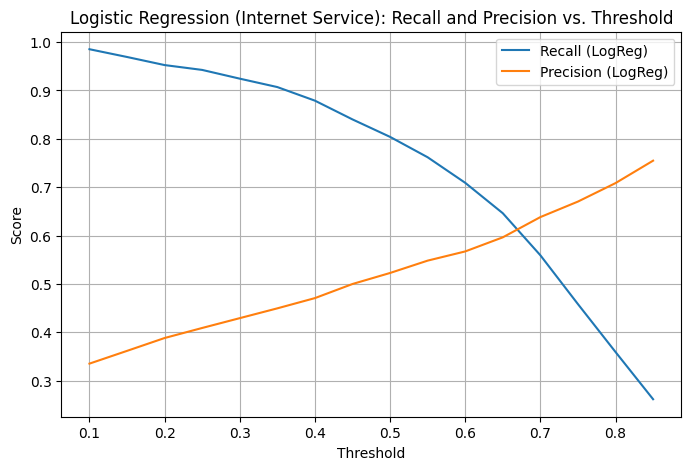

Logistic Regression (Internet Service) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.52
Threshold: 0.55, Recall: 0.76, Precision: 0.55
Threshold: 0.60, Recall: 0.71, Precision: 0.57


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


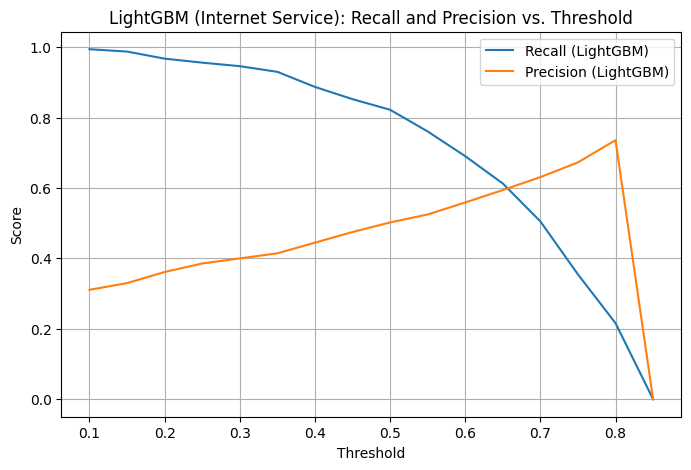

LightGBM (Internet Service) thresholds:
Threshold: 0.50, Recall: 0.82, Precision: 0.50
Threshold: 0.55, Recall: 0.76, Precision: 0.52


In [73]:
# Test probability thresholds for Logistic Regression (Internet Service) and LightGBM (Internet Service) models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_val_predict

# --- Logistic Regression (Internet Service) ---
# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_logreg = cross_val_predict(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls_logreg = []
precisions_logreg = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_logreg >= thresh).astype(int)
    recalls_logreg.append(recall_score(y_train, y_pred))
    precisions_logreg.append(precision_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_logreg, label='Recall (LogReg)')
plt.plot(thresholds, precisions_logreg, label='Precision (LogReg)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (Internet Service): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('Logistic Regression (Internet Service) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls_logreg, precisions_logreg):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

# --- LightGBM (Internet Service) ---
# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_lgbm = cross_val_predict(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, method='predict_proba')[:, 1]

recalls_lgbm = []
precisions_lgbm = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_lgbm >= thresh).astype(int)
    recalls_lgbm.append(recall_score(y_train, y_pred))
    precisions_lgbm.append(precision_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_lgbm, label='Recall (LightGBM)')
plt.plot(thresholds, precisions_lgbm, label='Precision (LightGBM)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM (Internet Service): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('LightGBM (Internet Service) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls_lgbm, precisions_lgbm):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

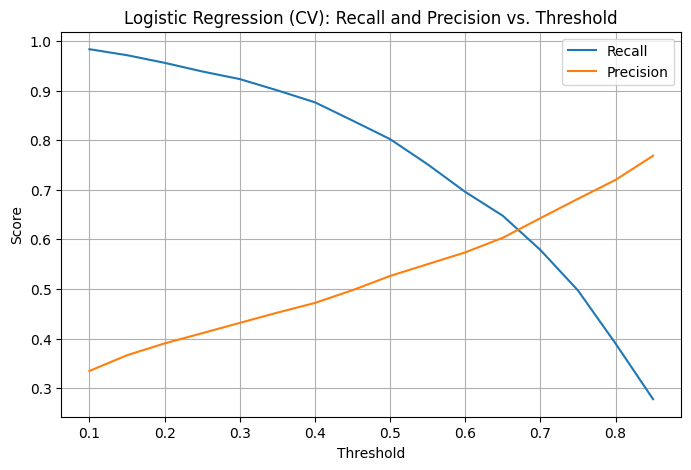

Logistic Regression (All Features) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.53
Threshold: 0.55, Recall: 0.75, Precision: 0.55


In [76]:
# Test probability thresholds for All Features Logistic Regression Model 

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba = cross_val_predict(best_logreg, X_train_final_clean, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
print('Logistic Regression (All Features) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

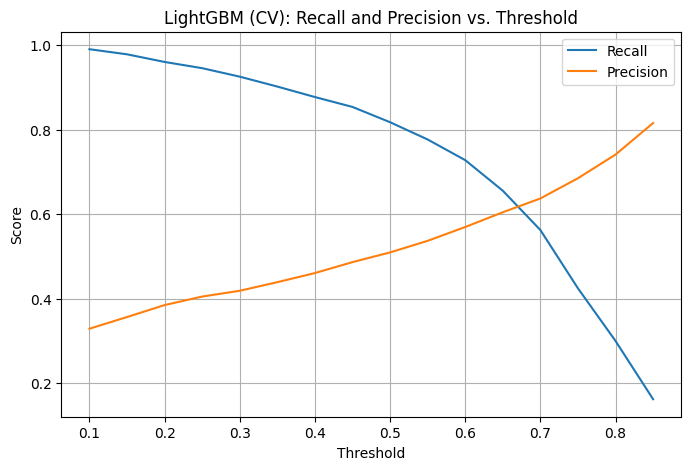

Logistic Regression (All Features) thresholds:
Threshold: 0.50, Recall: 0.82, Precision: 0.51
Threshold: 0.55, Recall: 0.78, Precision: 0.54
Threshold: 0.60, Recall: 0.73, Precision: 0.57


In [77]:
# Test probability thresholds for All-Feature LightGBM model using cross-validated predictions 

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_lgbm = cross_val_predict(best_lgbm, X_train_final_clean, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_lgbm >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
print('Logistic Regression (All Features) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

### Threshold Comparison Table: Recall and Precision for Key Models with recall >= 0.7 and precision >= 0.5 (Sorted by Threshold)
| Threshold | Model & Feature Set                | Recall | Precision |
|-----------|------------------------------------|--------|-----------|
| 0.50      | Logistic Regression (InternetSvc)  | 0.80   | 0.52      |
| 0.50      | LightGBM (InternetSvc)             | 0.82   | 0.50      |
| 0.50      | Logistic Regression (All Features) | 0.80   | 0.53      |
| 0.50      | LightGBM (All Features)            | 0.82   | 0.51      |
|           |                                    |        |           |
| 0.55      | Logistic Regression (InternetSvc)  | 0.76   | 0.55      |
| 0.55      | LightGBM (InternetSvc)             | 0.76   | 0.52      |
| 0.55      | Logistic Regression (All Features) | 0.75   | 0.55      |
| 0.55      | LightGBM (All Features)            | 0.78   | 0.54      |
|           |                                    |        |           |
| 0.60      | Logistic Regression (InternetSvc)  | 0.71   | 0.57      |
| 0.60      | LightGBM (All Features)            | 0.73   | 0.57      |

In [ ]:
# Calculate confusion matrices for 0.5 threshold on training data for Logistic Regression and LightGBM (Internet Service) models
from sklearn.metrics import confusion_matrix

# --- Logistic Regression (Internet Service) ---
best_logreg_internet_service.fit(X_train_internet_service, y_train)
y_proba_logreg_train = best_logreg_internet_service.predict_proba(X_train_internet_service)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (Internet Service, 0.5 threshold, training data):\n", cm_logreg_train)

# --- LightGBM (Internet Service) ---
best_lgbm_internet_service.fit(X_train_internet_service, y_train)
y_proba_lgbm_train = best_lgbm_internet_service.predict_proba(X_train_internet_service)[:, 1]
y_pred_lgbm_train = (y_proba_lgbm_train >= 0.5).astype(int)
cm_lgbm_train = confusion_matrix(y_train, y_pred_lgbm_train)
print("Confusion Matrix - LightGBM (Internet Service, 0.5 threshold, training data):\n", cm_lgbm_train)

# Calculate confusion matrices for 0.5 threshold on training data for "All Features Models"

# Logistic Regression (All Features)
best_logreg.fit(X_train_final_clean, y_train)
y_proba_logreg_train = best_logreg.predict_proba(X_train_final_clean)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (All Features, 0.5 threshold, training data):\n", cm_logreg_train)

# LightGBM (All Features)
best_lgbm.fit(X_train_final_clean, y_train)
y_proba_lgbm_train = best_lgbm.predict_proba(X_train_final_clean)[:, 1]
y_pred_lgbm_train = (y_proba_lgbm_train >= 0.5).astype(int)
cm_lgbm_train = confusion_matrix(y_train, y_pred_lgbm_train)
print("Confusion Matrix - LightGBM (All Features, 0.5 threshold, training data):\n", cm_lgbm_train)

Confusion Matrix - Logistic Regression (Internet Service, 0.5 threshold, training data):
 [[3031 1099]
 [ 283 1212]]
Confusion Matrix - LightGBM (Internet Service, 0.5 threshold, training data):
 [[2881 1249]
 [ 254 1241]]
Confusion Matrix - Logistic Regression (All Features, 0.5 threshold, training data):
 [[3052 1078]
 [ 282 1213]]
Confusion Matrix - LightGBM (All Features, 0.5 threshold, training data):
 [[2947 1183]
 [ 252 1243]]


### Confusion Matrices as Row-Wise Percentages (0.5 Threshold, Training Data)
| Model                                    | True Neg (%) | False Pos (%) | False Neg (%) | True Pos (%) |
|-------------------------------------------|--------------|---------------|---------------|--------------|
| Logistic Regression (Internet Service)    | 73.4         | 26.6          | 18.9          | 81.1         |
| LightGBM (Internet Service)               | 69.8         | 30.2          | 17.0          | 83.0         |
| Logistic Regression (All Features)        | 73.9         | 26.1          | 18.9          | 81.1         |
| LightGBM (All Features)                   | 71.4         | 28.6          | 16.9          | 83.1         |
*Rows: First two columns are actual 0 (True Neg, False Pos), last two are actual 1 (False Neg, True Pos). Percentages are row-normalized.*

| Threshold | Model & Feature Set                | Recall | Precision |
|-----------|------------------------------------|--------|-----------|
| 0.50      | Logistic Regression (InternetSvc)  | 0.80   | 0.52      |
| 0.50      | LightGBM (InternetSvc)             | 0.82   | 0.50      |
| 0.50      | Logistic Regression (All Features) | 0.80   | 0.53      |
| 0.50      | LightGBM (All Features)            | 0.82   | 0.51      |

**Comparison and Rationale:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I looked at models with the highest recall and a precision of at least 0.5 which is why I selected the 0.5 threshold. All of the models meet these criteria, at the 0.5 threshold. though both have higher recall than precision at each threshold. At the 0.50 threshold, Logistic Regression for both feature sets achieves a slightly lower recall (0.80 vs. 0.82) but marginally higher precisions compared to LightGBM. Overall, the models perform similarly, with only minor differences in these key metrics.

**Final Model Choice:**

Based on this evaluation, both of the Logistic Regression models were selected as the final models for the following main reasons:

1. They achieve recall above 0.7 and precision above 0.5, aligning with the business goal of identifying as many potential churners as possible while maintaining reasonable precision.
2. Logistic Regression models are simpler and more interpretable than LightGBM models, making it easier to explain and deploy.
3. The pruned model (Internet Service) can be used for understanding drivers of churn, guiding strategic decisions like pricing, contract changes, or targeted interventions. Its simplicity helps stakeholders trust and act on the insights.
4. The All Features features model can be used as the predictive model for flagging likely churners for retention campaigns, because it maximizes predictive accuracy.

Note: In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Selection & Test Set Results
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


In [ ]:
# Retrain Logistic Regression on full training data with best hyperparameters
# Best params were C=0.1, class_weight='balanced', max_iter=1000, solver='liblinear'

final_logreg = LogisticRegression(
    C=best_logreg.C,
    penalty=best_logreg.penalty,
    solver=best_logreg.solver,
    class_weight=best_logreg.class_weight,
    max_iter=1000,
    random_state=SEED
)

final_logreg.fit(X_train_final_clean, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Predict on test set
y_pred_final_logreg = final_logreg.predict(X_test_final_clean)
y_proba_final_logreg = final_logreg.predict_proba(X_test_final_clean)[:, 1]

In [ ]:
y_pred_final_logreg_thresh = (y_proba_final_logreg >= 0.5).astype(int)

In [ ]:

# Evaluate final logistic regression model on test set

from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix

# Compare predictions to true labels
recall = recall_score(y_test, y_pred_final_logreg_thresh)
precision = precision_score(y_test, y_pred_final_logreg_thresh)
roc_auc = roc_auc_score(y_test, y_proba_final_logreg)
cm = confusion_matrix(y_test, y_pred_final_logreg_thresh)

print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print("Confusion Matrix:")
print(cm)



Recall: 0.789
Precision: 0.494
ROC-AUC: 0.837
Confusion Matrix:
[[731 302]
 [ 79 295]]


In [ ]:
# Display percent confusion matrix for final logistic regression model (test set)
def confusion_matrix_percentages(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    percent_cm = np.round(100 * cm / row_sums, 4)
    return percent_cm

cm_pct = confusion_matrix_percentages(cm)
print("Confusion Matrix (% of actual class, row-normalized) - Final Logistic Regression (0.5 threshold, test set, %):\n", cm_pct)


Confusion Matrix (% of actual class, row-normalized) - Final Logistic Regression (0.5 threshold, test set, %):
 [[70.76 29.24]
 [21.12 78.88]]


In [ ]:
# Determine most important predictors for final logistic regression model

# Get feature names and coefficients
feature_names = X_train_final.columns
coefs = final_logreg.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
})

# Sort by absolute value of coefficient (importance)
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

# Display top 15 predictors
print(coef_df.head(15))

                                 feature  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855423         0.855423
1                                 tenure    -0.623566         0.623566
38             is_month_to_month_eng_Yes     0.609766         0.609766
9                       PhoneService_Yes    -0.548146         0.548146
35                 tenure_group_eng_7-12    -0.535424         0.535424
39  short_tenure_month_to_month_eng_True     0.526483         0.526483
12           InternetService_Fiber_optic     0.490031         0.490031
15                    OnlineSecurity_Yes    -0.458432         0.458432
21                       TechSupport_Yes    -0.427557         0.427557
30        PaymentMethod_Electronic_check     0.349644         0.349644
2                         MonthlyCharges     0.344321         0.344321
33                tenure_group_eng_25-48    -0.298623         0.298623
32                tenure_group_eng_13-24    -0.285256         0.285256
17    

In [ ]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df['readable_label'] = coef_df['feature'].map(feature_map).fillna(coef_df['feature'])

# Display top predictors with readable labels
print(coef_df[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

                          readable_label  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855423         0.855423
1                        Tenure (months)    -0.623566         0.623566
38                  Month-to-Month (Yes)     0.609766         0.609766
9                          Phone Service    -0.548146         0.548146
35            Tenure Group (7-12 months)    -0.535424         0.535424
39  Short Tenure & Month-to-Month (True)     0.526483         0.526483
12        Internet Service (Fiber Optic)     0.490031         0.490031
15                 Online Security (Yes)    -0.458432         0.458432
21                    Tech Support (Yes)    -0.427557         0.427557
30        PaymentMethod_Electronic_check     0.349644         0.349644


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_63058/4129743794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


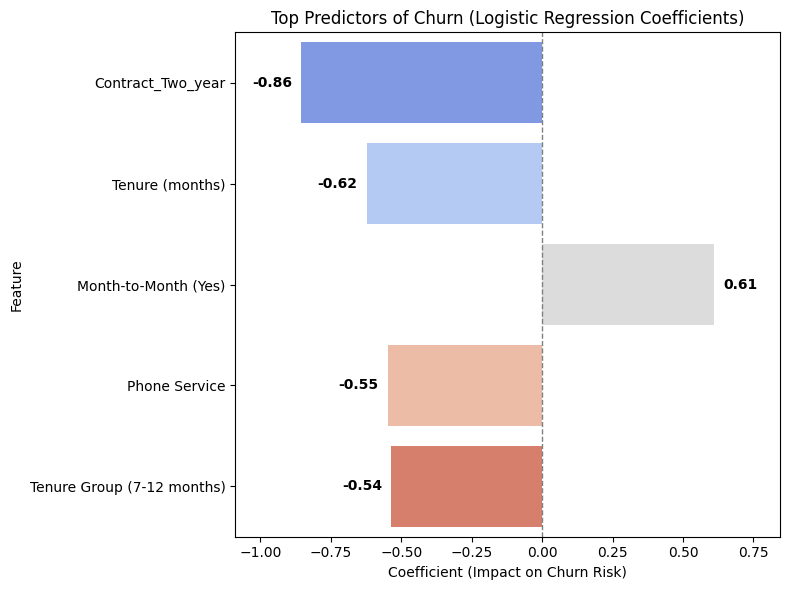

In [ ]:
# Plot top predictors for churn from logistic regression model

top_n = 5
top_coef = coef_df.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.show()

### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.


| Metric             | Validation Set | Test Set |
|--------------------|----------------|----------|
|Recall             | 0.80            | 0.79     |
|Precision          | 0.53            | 0.49     |
|ROC-AUC            | 0.845           | 0.837    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)  | 73.9           | 70.76      |
|    - False Pos (FP) | 26.1           | 29.24      |
|    - False Neg (FN) | 18.86           | 21.12      |
|    - True Pos (TP)  | 81.14           | 78.88      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.
